In [1]:
import siibra
from nilearn import plotting, image
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import plotly.graph_objects as go

import pyNN.neuron as sim
from pyNN import space
from pyNN.random import RandomDistribution, NumpyRNG
from pyNN.neuron import Projection, StaticSynapse, FixedNumberPreConnector
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
import statistics

[siibra:INFO] Version: 1.0.1-alpha.10
[siibra:WARNING] This is a development release. Use at your own risk.
[siibra:INFO] Please file bugs and issues at https://github.com/FZJ-INM1-BDA/siibra-python.
/home/tkmcg/neuron-env/lib/python3.12/site-packages/pyNN/neuron/__init__.py:14: UserWarning: mpi4py not available
  warnings.warn("mpi4py not available")


# Sphere

In [122]:
#class to implement sphere as was in original Fleming paper
class Sphere_random_point_generator():
    def __init__(self, radius, encapsulation_radius, stimulating_electrode_position):
        self.radius = radius
        self.encapsulation_radius = encapsulation_radius
        self.stimulating_electrode_position = stimulating_electrode_position

    def generate_positions(self, n):
        """Return `n` points distributed randomly with uniform density within the sphere with encapsulation layer"""
        num_points = n

        x_points = []
        y_points = []
        z_points = []

        # Sample angles - https://mathworld.wolfram.com/SpherePointPicking.html
        theta = 2*np.pi*np.random.uniform(0, 1, num_points)
        phi = np.arccos(2*np.random.uniform(0, 1, num_points)-1)

        # Sample radius
        r = self.radius*np.cbrt(np.random.uniform(0, 1, num_points))

        # Convert to Cartesian
        x_points = r*np.sin(phi)*np.cos(theta)
        y_points = r*np.sin(phi)*np.sin(theta)
        z_points = r*np.cos(phi) + self.stimulating_electrode_position[2]

        invalid_points = (x_points**2 + y_points**2 < self.encapsulation_radius**2) 

        while np.any(invalid_points):
            n = invalid_points.sum()

            theta = 2*np.pi*np.random.uniform(0, 1, n)
            phi = np.arccos(2*np.random.uniform(0, 1, n)-1)
            r = self.radius * np.cbrt(np.random.uniform(0, 1, n))

            x_points[invalid_points] = r*np.sin(phi)*np.cos(theta)
            y_points[invalid_points] = r*np.sin(phi)*np.sin(theta)
            z_points[invalid_points] = r*np.cos(phi) + self.stimulating_electrode_position[2]

            invalid_points = (x_points**2 + y_points**2 < self.encapsulation_radius**2) 

        points = np.column_stack((x_points, y_points, z_points))
        return points


In [126]:
encapsulation = 500
stimulating_electrode_position = np.array([0,0,0])
ellipse = Sphere_random_point_generator(2000, encapsulation, stimulating_electrode_position)
STN_space = ellipse.generate_positions(10000)


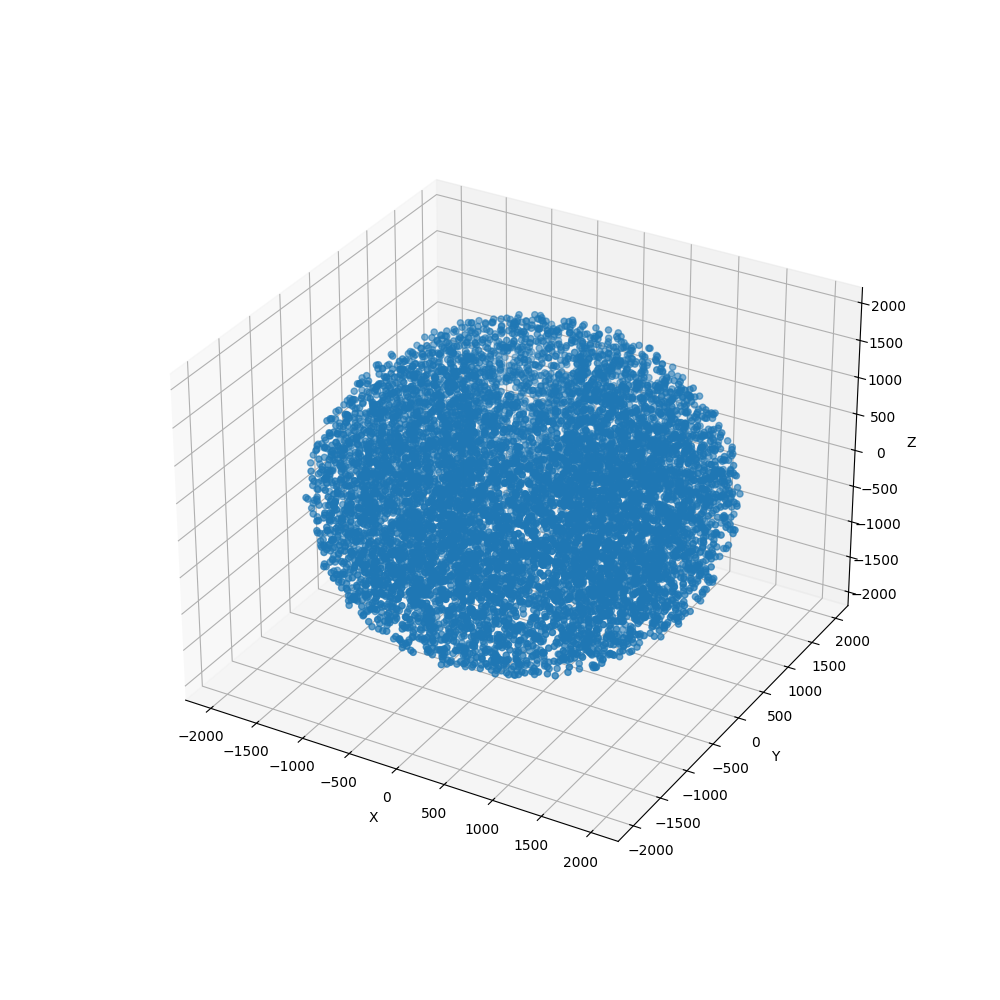

In [127]:
###### plot where the neurons are in the STn space #########
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib widget

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

#interpolate the values for the ctx neurons
x_points_clean_ctx = STN_space[:,0]
y_points_clean_ctx = STN_space[:,1]
z_points_clean_ctx = STN_space[:,2]
ax.scatter(x_points_clean_ctx, y_points_clean_ctx, z_points_clean_ctx)

plt.show()

In [128]:
##### Add in the STN neurons and change the geometry to match the coupling project with DC current ####
v_init = -68
rng_seed = 856
n = 200
rotation_angle = 0.610865
encapsulation = 500
stimulating_electrode_position = np.array([0,0,0])

############ Setup the simulation##########
sim.setup(timestep=0.01)


###########set up the neuron type##############
cortical_type = sim.HH_cond_exp()
STN_type = sim.HH_cond_exp()

########## create a population of neurons ###############
cortical_pop = sim.Population(n, cortical_type, initial_values={'v': v_init}, label="Cortical neurons")
STN_pop = sim.Population(n, STN_type, initial_values={'v': v_init}, label="STN neurons")

######## positions of the cells #######################
ellipse = Sphere_random_point_generator(2000, encapsulation, stimulating_electrode_position)
cortical_space = ellipse.generate_positions(n)
STN_space = ellipse.generate_positions(n)

cortical_pop.positions[0], cortical_pop.positions[1],cortical_pop.positions[2] = cortical_space[:,0], cortical_space[:,1], cortical_space[:,2]
STN_pop.positions[0], STN_pop.positions[1],STN_pop.positions[2] = STN_space[:,0], STN_space[:,1], STN_space[:,2]

sim.end()

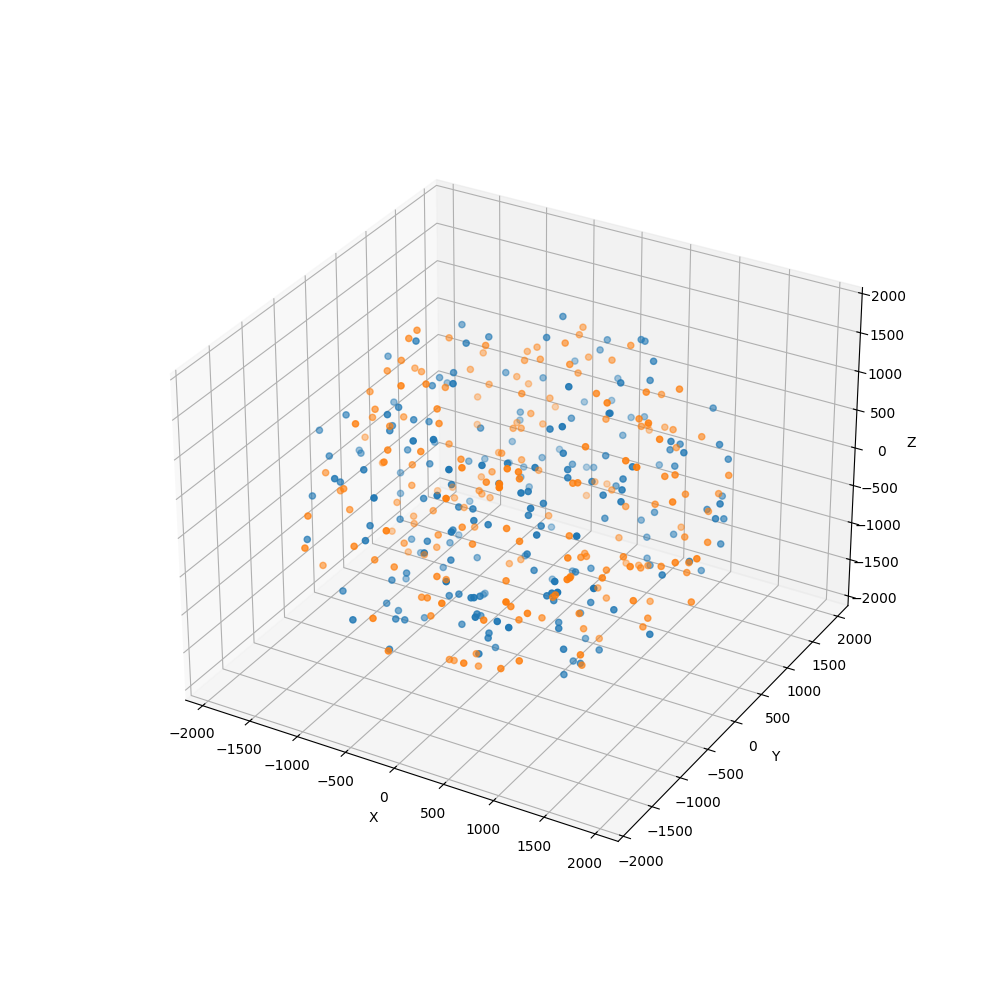

In [129]:
###### plot where the neurons are in the STn space #########
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib widget

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

#interpolate the values for the ctx neurons
x_points_clean_ctx = cortical_pop.positions[0]
y_points_clean_ctx = cortical_pop.positions[1]
z_points_clean_ctx = cortical_pop.positions[2]
ax.scatter(x_points_clean_ctx, y_points_clean_ctx, z_points_clean_ctx)

#interpolate the values for the stn neurons
x_points_clean_stn = STN_pop.positions[0]
y_points_clean_stn = STN_pop.positions[1]
z_points_clean_stn = STN_pop.positions[2]
ax.scatter(x_points_clean_stn, y_points_clean_stn, z_points_clean_stn)

plt.show()

# Ellipse

In [117]:
#class to implement elliptical shape
class Ellipsoid_random_point_generator():
    """
    Represents a ellipitical volume within which neurons may be distributed.
    """
    def __init__(self, radius_x, radius_y, radius_z, encapsulation_radius, stimulating_electrode_position, rotation_angle):
        self.radius_x = radius_x
        self.radius_y = radius_y
        self.radius_z = radius_z
        self.encapsulation_radius = encapsulation_radius
        self.stimulating_electrode_position = stimulating_electrode_position
        self.rotation_angle = rotation_angle

    def generate_positions(self, n):
        """Return `n` points distributed randomly with uniform density within the eclipse"""
        num_points = n

        #rotation angle of an ellipse defines its tilt relative to the standard x-axis
        self.rotation_angle = np.pi/2 - self.rotation_angle

        x_points = []
        y_points = []
        z_points = []


        # Generate a random point inside the sphere
        theta = 2*np.pi*np.random.uniform(0, 1, num_points)
        phi = np.arccos(2*np.random.uniform(0, 1, num_points)-1)
        x_radius = self.radius_x*np.cbrt(np.random.uniform(0, 1, num_points))
        y_radius = self.radius_y*np.cbrt(np.random.uniform(0, 1, num_points))
        z_radius = self.radius_z*np.cbrt(np.random.uniform(0, 1, num_points))

        x = x_radius * np.sin(phi) * np.cos(theta)
        y = y_radius * np.sin(phi) * np.sin(theta)
        z = z_radius * np.cos(phi)+ self.stimulating_electrode_position[2]

        invalid = (x**2 + y**2 < self.encapsulation_radius**2) 

        while np.any(invalid):
            n = invalid.sum()
            # Generate a random point inside the sphere
            theta = 2*np.pi*np.random.uniform(0, 1, n)
            phi = np.arccos(2*np.random.uniform(0, 1, n)-1)
            x_radius = self.radius_x*np.cbrt(np.random.uniform(0, 1, n))
            y_radius = self.radius_y*np.cbrt(np.random.uniform(0, 1, n))
            z_radius = self.radius_z*np.cbrt(np.random.uniform(0, 1, n))

            x[invalid] = x_radius * np.sin(phi) * np.cos(theta)
            y[invalid] = y_radius * np.sin(phi) * np.sin(theta)
            z[invalid] = z_radius * np.cos(phi)+ self.stimulating_electrode_position[2]

            invalid = (x**2 + y**2 < self.encapsulation_radius**2)

        #rotate around the z axis
        x_points = x*np.cos(self.rotation_angle) - y*np.sin(self.rotation_angle)
        y_points = y*np.cos(self.rotation_angle) + x*np.sin(self.rotation_angle)
        z_points = z
        
        points = np.column_stack((x_points, y_points, z_points))
        return points


In [120]:
encapsulation_radius = 1000
stimulating_electrode_position = np.array([0,0,0])
ellipse = Ellipsoid_random_point_generator(4176,3080,2961, encapsulation_radius, stimulating_electrode_position, 0.610865)
STN_space = ellipse.generate_positions(10000)

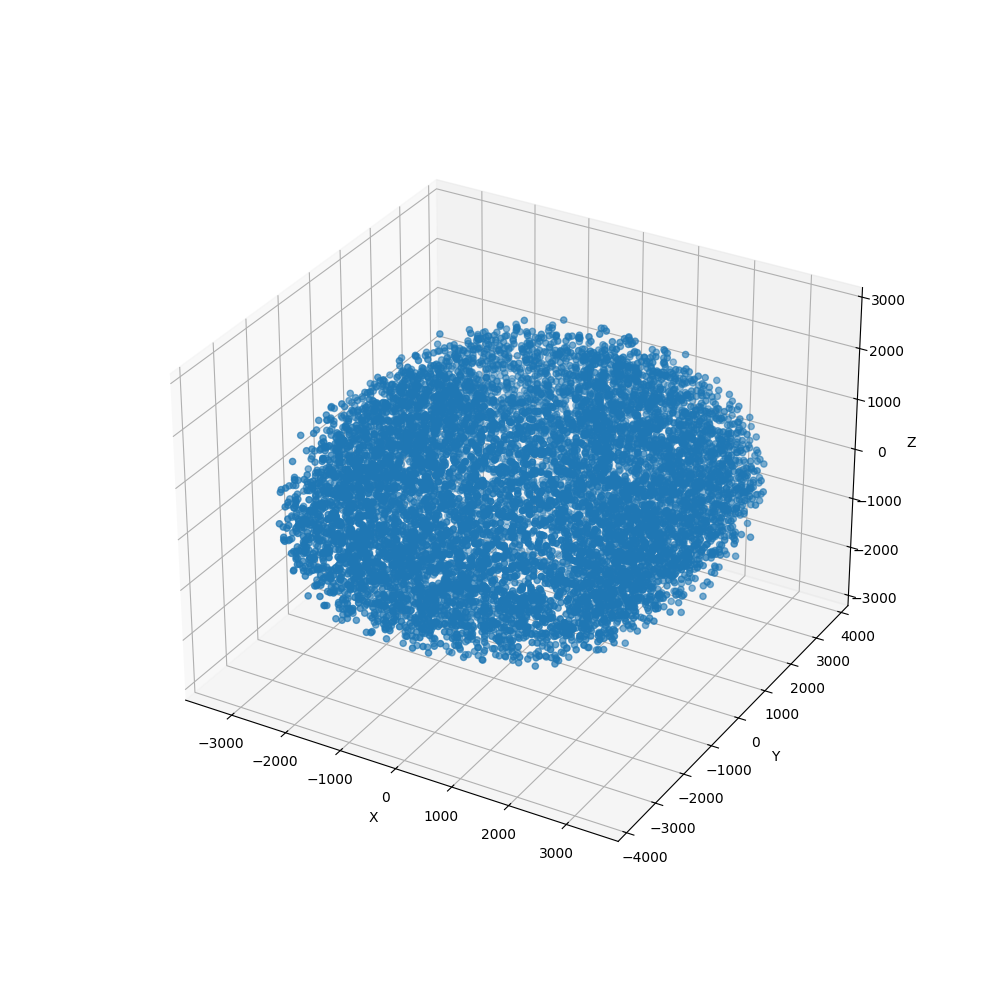

In [121]:
###### plot where the neurons are in the STn space #########
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib widget

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

#interpolate the values for the ctx neurons
x_points_clean_ctx = STN_space[:,0]
y_points_clean_ctx = STN_space[:,1]
z_points_clean_ctx = STN_space[:,2]
ax.scatter(x_points_clean_ctx, y_points_clean_ctx, z_points_clean_ctx)

plt.show()

In [131]:
##### Add in the STN neurons and change the geometry to match the coupling project with DC current ####
v_init = -68
rng_seed = 856
n = 200
rotation_angle = 0.610865
encapsulation_radius = 500
stimulating_electrode_position = np.array([0,0,0])

############ Setup the simulation##########
sim.setup(timestep=0.01)


###########set up the neuron type##############
cortical_type = sim.HH_cond_exp()
STN_type = sim.HH_cond_exp()

########## create a population of neurons ###############
cortical_pop = sim.Population(n, cortical_type, initial_values={'v': v_init}, label="Cortical neurons")
STN_pop = sim.Population(n, STN_type, initial_values={'v': v_init}, label="STN neurons")

######## positions of the cells #######################
ellipse = Ellipsoid_random_point_generator(4176,3080,2961, encapsulation_radius, stimulating_electrode_position, 0.610865)
cortical_space = ellipse.generate_positions(n)
STN_space = ellipse.generate_positions(n)

cortical_pop.positions[0], cortical_pop.positions[1],cortical_pop.positions[2] = cortical_space[:,0], cortical_space[:,1], cortical_space[:,2]
STN_pop.positions[0], STN_pop.positions[1],STN_pop.positions[2] = STN_space[:,0], STN_space[:,1], STN_space[:,2]

sim.end()

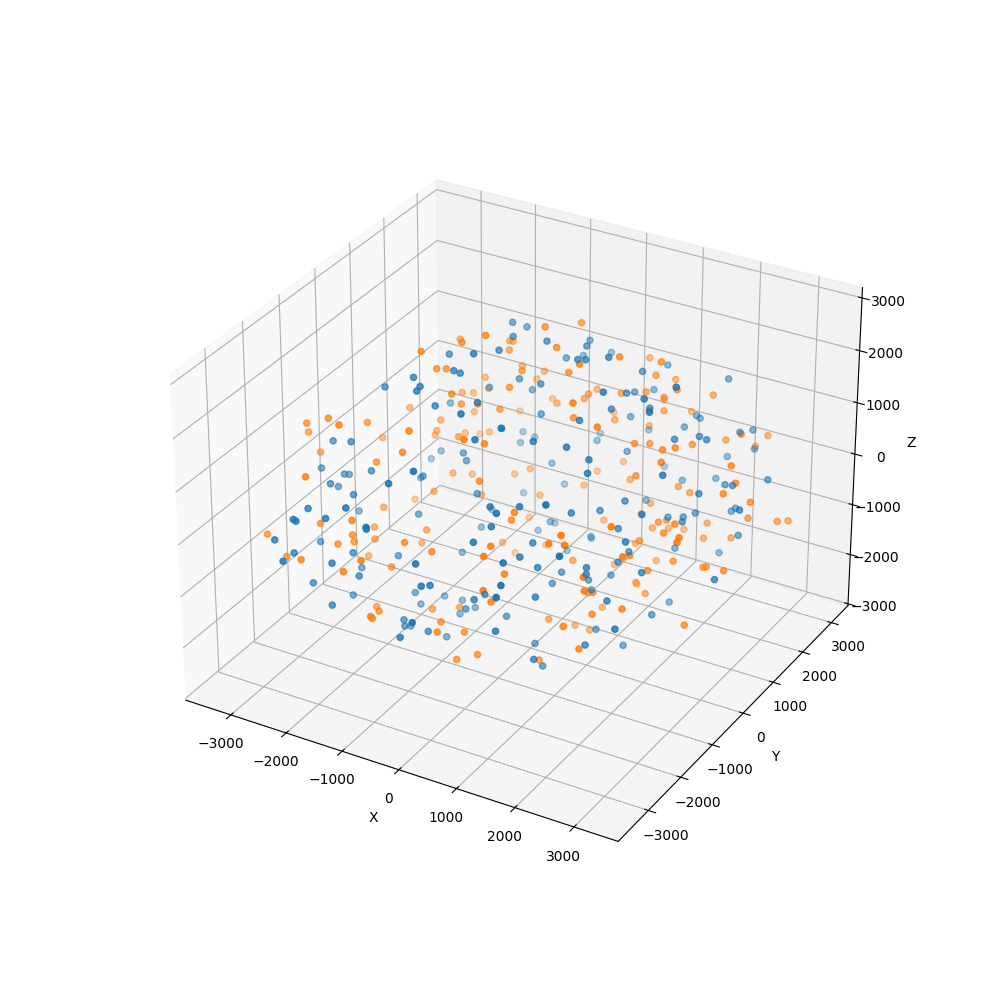

In [132]:
###### plot where the neurons are in the STn space #########
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib widget

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

#interpolate the values for the ctx neurons
x_points_clean_ctx = cortical_pop.positions[0]
y_points_clean_ctx = cortical_pop.positions[1]
z_points_clean_ctx = cortical_pop.positions[2]
ax.scatter(x_points_clean_ctx, y_points_clean_ctx, z_points_clean_ctx)

#interpolate the values for the stn neurons
x_points_clean_stn = STN_pop.positions[0]
y_points_clean_stn = STN_pop.positions[1]
z_points_clean_stn = STN_pop.positions[2]
ax.scatter(x_points_clean_stn, y_points_clean_stn, z_points_clean_stn)

plt.show()

# Julich

In [56]:
#class to get random points based on the STN in the Julich Brain CYTOARCHITECTUR                               E
class Julich_brain_cyto_random_point_generator:
    def __init__(self,parcellation, region, space, stimulating_electrode_position, encapsulation_radius):
        #obtain the brain region required
        self.region = siibra.get_region(parcellation, region)

        #get the space required
        self.space = self.region.spaces.get(space)


        self.region_map = self.region.get_regional_map(space, maptype="statistical")
        self.NIfTI_region = self.region_map.fetch()
        self.region_data = self.NIfTI_region.get_fdata()
        self.affine = self.NIfTI_region.affine

        ## Get voxel indices (i,j,k) of valid voxels
        self.region_data_indices = np.argwhere(self.region_data > 0)

        #stimulating electrode position and encapsulation
        self.stimulating_electrode_position = stimulating_electrode_position
        self.encapsulation_radius = encapsulation_radius


    def generate_positions(self, number_points):
        indices = np.random.choice(len(self.region_data_indices), size = number_points)
        voxel_coords = self.region_data_indices[indices]

        offsets = np.random.normal(0, 0.4, size=(number_points, 3))
        voxel_points = voxel_coords + offsets

        ones = np.ones((number_points, 1))
        vox_hom = np.hstack([voxel_points, ones])          # (N,4)
        world_points = (self.affine @ vox_hom.T).T[:, :3]

        #remove points from the encapsulation layer
        x_coordinates = world_points[:, 0] - self.stimulating_electrode_position[0]
        y_coordinates = world_points[:, 1] - self.stimulating_electrode_position[1]
        

        mask = ~(x_coordinates**2 + y_coordinates**2 < self.encapsulation_radius**2)

        if mask.sum() < number_points:
            # recursively fill remaining points
            missing = number_points - mask.sum()
            extra = self.generate_positions(missing)
            world_points = np.vstack([world_points[mask], extra])
        else:
            world_points = world_points[mask][:number_points]


        return world_points


In [57]:
parcellation = "JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1" 
region = "STN (Subthalamus) right"
space = "MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC"
stimulating_electrode = np.array([11600,-16200,-9100])/1000
encapsulation = 1.135

ellipse = Julich_brain_cyto_random_point_generator(parcellation,region,space, stimulating_electrode, encapsulation)
STN_space = ellipse.generate_positions(10000)

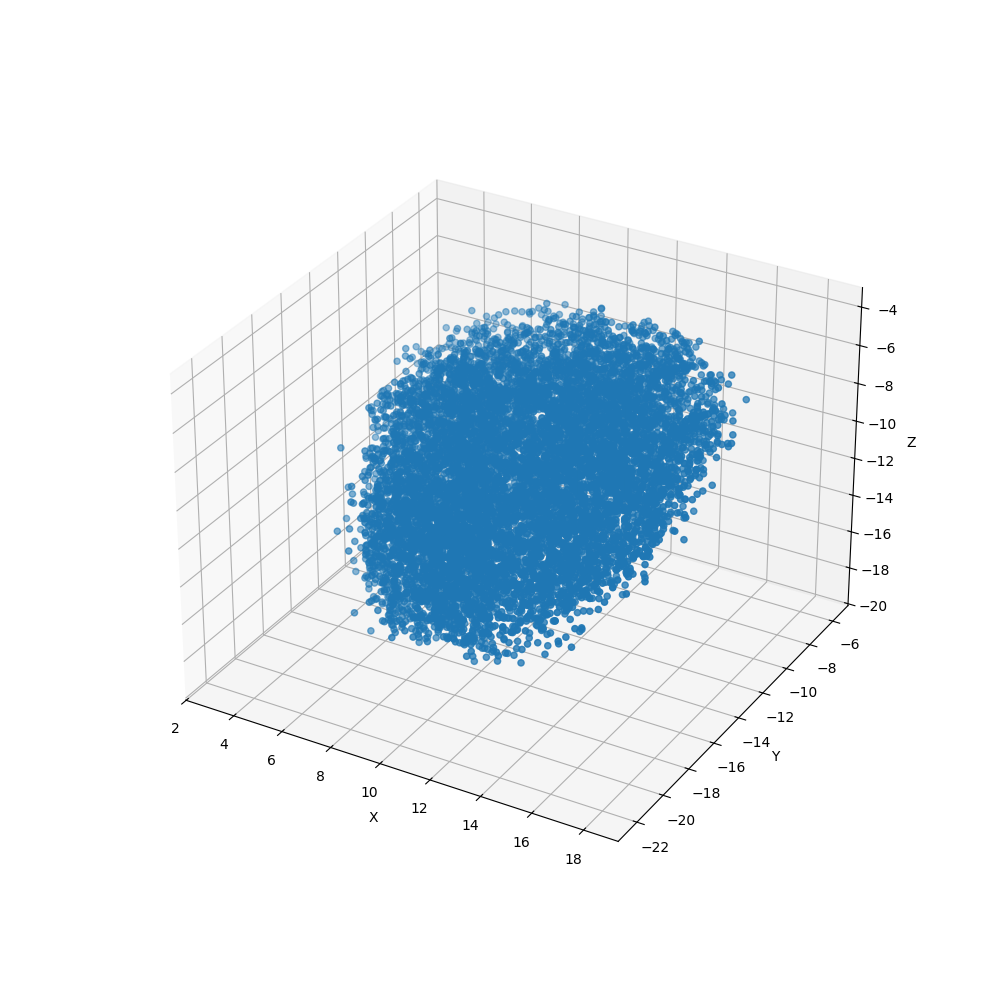

In [58]:
###### plot where the neurons are in the STn space #########
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib widget

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

#interpolate the values for the ctx neurons
x_points_clean_ctx = STN_space[:,0]
y_points_clean_ctx = STN_space[:,1]
z_points_clean_ctx = STN_space[:,2]
ax.scatter(x_points_clean_ctx, y_points_clean_ctx, z_points_clean_ctx)

plt.show()

In [24]:
##### Add in the STN neurons and change the geometry to match the coupling project with DC current ####
v_init = -68
rng_seed = 856
n = 200
rotation_angle = 0.610865
encapsulation_radius = 500
stimulating_electrode_position = np.array([0,0,0])

############ Setup the simulation##########
sim.setup(timestep=0.01)


###########set up the neuron type##############
cortical_type = sim.HH_cond_exp()
STN_type = sim.HH_cond_exp()

########## create a population of neurons ###############
cortical_pop = sim.Population(n, cortical_type, initial_values={'v': v_init}, label="Cortical neurons")
STN_pop = sim.Population(n, STN_type, initial_values={'v': v_init}, label="STN neurons")

######## positions of the cells #######################
ellipse = Julich_brain_cyto_random_point_generator(parcellation,region,space, stimulating_electrode, encapsulation)
cortical_space = ellipse.generate_positions(n)
STN_space = ellipse.generate_positions(n)

cortical_pop.positions[0], cortical_pop.positions[1],cortical_pop.positions[2] = cortical_space[:,0], cortical_space[:,1], cortical_space[:,2]
STN_pop.positions[0], STN_pop.positions[1],STN_pop.positions[2] = STN_space[:,0], STN_space[:,1], STN_space[:,2]

sim.end()

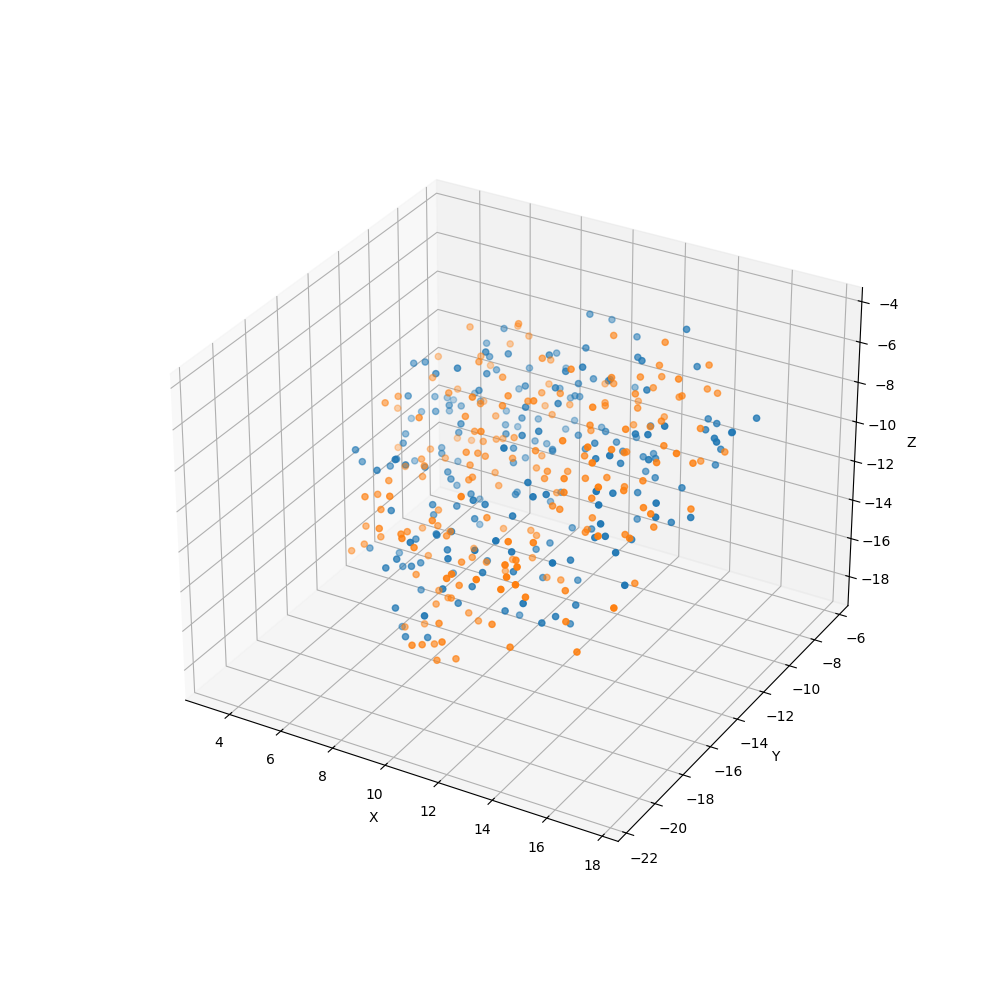

In [25]:
###### plot where the neurons are in the STn space #########
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib widget

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

#interpolate the values for the ctx neurons
x_points_clean_ctx = cortical_pop.positions[0]
y_points_clean_ctx = cortical_pop.positions[1]
z_points_clean_ctx = cortical_pop.positions[2]
ax.scatter(x_points_clean_ctx, y_points_clean_ctx, z_points_clean_ctx)

#interpolate the values for the stn neurons
x_points_clean_stn = STN_pop.positions[0]
y_points_clean_stn = STN_pop.positions[1]
z_points_clean_stn = STN_pop.positions[2]
ax.scatter(x_points_clean_stn, y_points_clean_stn, z_points_clean_stn)

plt.show()